### Start

In [1]:
from osgeo import gdal,osr
import os 
import numpy as np
from datetime import date
import matplotlib.pyplot as plt 
import pandas as pd 


In [2]:
def getrmse(y,x):
    return np.sqrt(np.sum(np.square(y-x))/len(y))

def getmae(y,x):
    return np.sum(np.abs(y-x))/len(y)

def getbias(y,x):
    """
    y: 真值，
    x: 估计值
    """
    return np.sum(x-y)/len(y)

def getunRMSE(y,x):
    t1 = (x-np.mean(x))
    t2 = (y-np.mean(y))
    return np.sqrt(np.sum(np.square(t1-t2))/len(y))

def getR(y,x):
    return np.corrcoef(y,x)[1,0]


In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 1000)   # 或 1000
pd.set_option("display.max_colwidth", None)


#### 处理SMAP SM 提取结果，把xls变为csv，把结果整合到1个表里

In [7]:
rootPath = 'E:/SM_results_7_dielectric_model/Results/'
os.chdir(rootPath)
savePath = 'E:/SM_results_7_dielectric_model/Results/Site_Extract_Inv_withSMAP/'
if not os.path.exists(savePath):
    os.makedirs(savePath)
for file in os.listdir(rootPath+'Site_Extract_Inv'):
    data_site = pd.read_csv(os.path.join(rootPath+'Site_Extract_Inv',file))
    file_smap = [i for i in os.listdir(os.path.join(rootPath,'Validation_SMAP')) if '+'.join(file.split('+')[:2]) == i.split('_')[0]][0]
    data_smap = pd.read_excel(os.path.join(rootPath+'Validation_SMAP',file_smap))
    data_smap['Date'] = data_smap['Date'].dt.strftime('%Y/%m/%d')
    data_smap = data_smap[['Date','SM_SCV','SM_SCH','SM_DCA']]
    data = data_site.merge(data_smap,on='Date',how='inner')
    data = data[['Network','Station','Lon','Lat','rowID','colID','Dem',
                    'Clay','Sand','Silt','SOM','Bulk','ECe','LC',
                    'Date','NDVI','SM_Obs','ST','TBv','VOD',
                    'SMS_Dob','SMS_Wang','SMS_Mir09','SMS_Mir13','SMS_Mir19','SMS_Park',
                    'SMG_Dob','SMG_Wang','SMG_Mir09','SMG_Mir13','SMG_Mir19','SMG_Park','SMG_Top',
                    'SM_SCV','SM_SCH','SM_DCA']]
    data.columns = ['Network','Station','Lon','Lat','rowID','colID','Dem',
                    'Clay','Sand','Silt','SOM','Bulk','ECe','LC',
                    'Date','NDVI','SM_Obs','ST','TBv','VOD',
                    'SMS_Dob','SMS_Wang','SMS_Mir09','SMS_Mir13','SMS_Mir19','SMS_Park',
                    'SMG_Dob','SMG_Wang','SMG_Mir09','SMG_Mir13','SMG_Mir19','SMG_Park','SMG_Top',
                    'SMG_SCV','SMG_SCH','SMG_DCA']
    if data.dropna().shape[0] > 30: # 删除有效值小于30的站点
        data.to_csv(os.path.join(savePath,'+'.join(file.split('+')[:2])+'+Extract_Inv_withSMAP'+'.csv'),index=False)


#### 处理新的Wang反演的结果，整理到之前的表格中

In [64]:
pathWang = 'E:/SM_results_7_dielectric_model/Results/validation_merge_models/'
pathSMAP = 'E:/SM_results_7_dielectric_model/Results/Site_Extract_Inv_withSMAP_AG_withCoarseSoil_BestModel/'
pathSave = 'E:/SM_results_7_dielectric_model/Results/Site_Extract_Inv_withSMAP_AG_withCoarseSoil_BestModel_newWang/'

os.makedirs(pathSave,exist_ok=True)

fileNotMath = []

for file in os.listdir(pathSMAP):
    tmp = pd.read_csv(os.path.join(pathSMAP,file))
    name = '+'.join(file.split('+')[:2])
    #print(name,tmp.shape[0])
    cols = tmp.columns.tolist()
    fileMatch = [i for i in os.listdir(pathWang) if name == i.split('_')[0]]
    if len(fileMatch) > 0:
        #print(fileMatch)
        fileMatch = fileMatch[0]
        tmp_wang = pd.read_excel(os.path.join(pathWang,fileMatch))
        tmp_wang['Date'] = pd.to_datetime(tmp_wang['Date'])
        tmp_wang['Date'] = tmp_wang['Date'].dt.strftime('%Y/%m/%d')
        tmp_wang = tmp_wang[['Date','SM_Wang']]
        tmp_wang.columns = ['Date','SMG_Wang']
        tmp = tmp.drop('SMG_Wang',axis=1).merge(tmp_wang,how='inner',on='Date')
        tmp[cols].to_csv(os.path.join(pathSave,file),index=False)
    else:
        fileNotMath.append(file)

fileNotMath

[]

#### 处理提取和反演的数据，把xls变为csv，把反演和提取结果整合到1个表里

In [35]:
rootPath = 'E:/SM_results_7_dielectric_model/Results/'
os.chdir(rootPath)
savePath = 'E:/SM_results_7_dielectric_model/Results/Site_Extract_Inv/'
if not os.path.exists(savePath):
    os.makedirs(savePath)
for file in os.listdir(rootPath+'Inversion_Site'):
    data_site = pd.read_excel(os.path.join(rootPath+'Inversion_Site',file))
    data_site['Date'] = data_site['Date'].dt.strftime('%Y/%m/%d')
    file_grid = [i for i in os.listdir(os.path.join(rootPath,'Extracted_Grid')) if file.split('_')[0] == i.split('_')[0]][0]
    data_grid = pd.read_excel(os.path.join(rootPath+'Extracted_Grid',file_grid))
    data_grid['Date'] = data_grid['Date'].dt.strftime('%Y/%m/%d')
    data_grid[['Dobson','Wang','Mironov2009','Mironov2013','Mironov2019','Park','Topp']] = data_grid[['Dobson','Wang','Mironov2009','Mironov2013','Mironov2019','Park','Topp']].replace(0,np.nan)
    data = data_site.merge(data_grid,on='Date',how='inner')
    data = data[['Network','Station','Lon','Lat','row','col','Dem',
                 'clay_5','sand_5','silt_5','soc_5','bulk_5','ECe','LC_IGBP',
                 'Date','NDVI','Value','ST','TBV','VOD',
                 'SM_Dobson','SM_Wang','SM_Mir2009','SM_Mir2013','SM_Mir2019','SM_Park2019',
                 'Dobson','Wang','Mironov2009','Mironov2013','Mironov2019','Park','Topp']]
    data.columns = ['Network','Station','Lon','Lat','rowID','colID','Dem',
                    'Clay','Sand','Silt','SOM','Bulk','ECe','LC',
                    'Date','NDVI','SM_Obs','ST','TBv','VOD',
                    'SMS_Dob','SMS_Wang','SMS_Mir09','SMS_Mir13','SMS_Mir19','SMS_Park',
                    'SMG_Dob','SMG_Wang','SMG_Mir09','SMG_Mir13','SMG_Mir19','SMG_Park','SMG_Top']
    if data.dropna().shape[0] > 30: # 删除有效值小于30的站点
        data.to_csv(os.path.join(savePath,file.split('_')[0]+'+Extract_Inv'+'.csv'),index=False)


#### 针对Site Inversion结果对每个站点进行评估

In [35]:
rootPath = 'E:/SM_results_7_dielectric_model/Results/Site_Extract_Inv_withSMAP_AG_withCoarseSoil_BestModel/'
os.chdir(rootPath)
stations = []
for file in os.listdir(rootPath):
    s = pd.read_csv(file)
    s['Network'] = s['Network'].astype('str')
    s['Station'] = s['Station'].astype('str')
    t = s['Network'].iloc[0]+'+'+s['Station'].iloc[0]
    stations.append(t)
stations = set(stations)
stations = list(stations)
stations = sorted(stations)
print(s.columns)

Index(['Network', 'Station', 'Lon', 'Lat', 'rowID', 'colID', 'Dem', 'Clay',
       'Sand', 'Silt', 'SOM', 'Bulk', 'ECe', 'LC', 'Date', 'NDVI', 'SM_Obs',
       'ST', 'TBv', 'VOD', 'SMS_Dob', 'SMS_Wang', 'SMS_Mir09', 'SMS_Mir13',
       'SMS_Mir19', 'SMS_Park', 'SMG_Dob', 'SMG_Wang', 'SMG_Mir09',
       'SMG_Mir13', 'SMG_Mir19', 'SMG_Park', 'SMG_Top', 'SMG_SCV', 'SMG_SCH',
       'SMG_DCA', 'ASCAT', 'GLDAS', 'Clay_Coarse', 'Sand_Coarse',
       'Silt_Coarse', 'SOM_Coarse', 'Bulk_Coarse', 'bestModel'],
      dtype='object')


In [41]:
rootPath = 'E:/SM_results_7_dielectric_model/Results/Site_Extract_Inv_withSMAP_AG_withCoarseSoil_BestModel/'
os.chdir(rootPath)
files = os.listdir(rootPath)
mae = []
rmse = []
r = []
bias = []
unRMSE = []
network = []
station = []
Number = []
Model = []
Clay = []
Sand = []
Silt = []
Som = []
ndvi = []
St = []
ECe = []
Lc = []
rowcol = []

for site in stations:
    file_sets = [file for file in files if site in file]
    s = pd.concat([pd.read_csv(i) for i in file_sets])
    for model in ['Dob','Wang','Mir09','Mir13','Mir19','Park','SCH','SCV','DCA']:
        t = s[['SM_Obs','SMG_Dob','SMG_Wang','SMG_Mir09','SMG_Mir13','SMG_Mir19','SMG_Park','SMG_SCH','SMG_SCV','SMG_DCA','rowID','colID']].dropna() #SM_CCI
        if model in ['SCH','SCV','DCA']:
            Pname = 'SMG_'+model
        else:
            Pname = 'SMG_'+model
        Tname = 'SM_Obs'
        #前面的是真实，后面的预测值
        mae.append(getmae(t[Tname],t[Pname]))
        rmse.append(getrmse(t[Tname],t[Pname]))
        r.append(getR(t[Tname],t[Pname]))
        bias.append(getbias(t[Tname],t[Pname]))
        unRMSE.append(getunRMSE(t[Tname],t[Pname]))
        station.append(site.split('+')[1])
        network.append(site.split('+')[0])
        Number.append(t.shape[0])
        Model.append(model)
        Clay.append(s['Clay'].mean())
        Sand.append(s['Sand'].mean())
        Silt.append(s['Silt'].mean())
        Som.append(s['SOM'].mean())
        ndvi.append(s['NDVI'].mean())
        ECe.append(s['ECe'].mean())
        Lc.append(s['LC'].mode().values[0])
        rowcol.append(str(s['rowID'][0])+'-'+str(s['colID'][0]))

In [42]:
df = pd.DataFrame({
    'Network':network,
    'Station': station,
    'RowCol':rowcol,
    'Model':Model,
    'Clay':Clay,
    'Sand':Sand,
    'Silt':Silt,
    'SOM':Som,
    'ECe':ECe,
    'LC':Lc,
    'mae': mae,
    'rmse': rmse,
    'ubRMSE': unRMSE,
    'bias': bias,
    'r': r,
    'Number':Number
})

keep = ['Dob','Wang','Mir09','Mir13','Mir19','Park','SCH','SCV','DCA']
print('Number of Network:',len(set(network)))
print(df.groupby(['Model'])[['mae','rmse','ubRMSE','r','bias','Number']].mean())
print(df.groupby(['Model'])[['mae','rmse','ubRMSE','r','bias','Number']].median())
df.dropna().sort_values(['Network','Station']).to_csv('E:/SM_results_7_dielectric_model/Evaluation/metrics_grid_site_scale.csv',index=False)
#df['Sand_bin'] = pd.qcut(df['Sand'],q=10,labels=False)+1
#df.groupby(['Sand_bin','Model'])[['mae','rmse','ubRMSE','r','bias']].mean()

Number of Network: 37
            mae      rmse    ubRMSE         r      bias      Number
Model                                                              
DCA    0.083385  0.102647  0.067856  0.661111 -0.003922  698.782811
Dob    0.096405  0.117658  0.076459  0.635925 -0.010769  698.782811
Mir09  0.094830  0.115079  0.073584  0.648183  0.024612  698.782811
Mir13  0.094344  0.114563  0.073338  0.647822  0.023909  698.782811
Mir19  0.121773  0.141118  0.076628  0.654158  0.083043  698.782811
Park   0.097906  0.117933  0.072625  0.645592 -0.024103  698.782811
SCH    0.090466  0.110279  0.069853  0.639121 -0.049893  698.782811
SCV    0.080503  0.099237  0.066211  0.655649 -0.010719  698.782811
Wang   0.124968  0.145211  0.079967  0.625791  0.077062  698.782811
            mae      rmse    ubRMSE         r      bias  Number
Model                                                          
DCA    0.065479  0.079768  0.057798  0.696583  0.005238   436.0
Dob    0.079554  0.097865  0.067224  0

In [73]:
df.groupby(['Network','Model'])[['mae','rmse','ubRMSE','r','bias']].mean()

mae      rmse    ubRMSE         r      bias
Network           Model                                                  
AMMA-CATCH        Dob    0.041433  0.060469  0.049222  0.835877  0.023160
                  Mir09  0.067852  0.086073  0.053173  0.867657  0.066196
                  Mir13  0.068510  0.087516  0.054646  0.866387  0.066778
                  Mir19  0.106814  0.131964  0.076393  0.881186  0.103088
                  Park   0.042771  0.060789  0.046721  0.856166  0.035426
                  Wang   0.075547  0.095330  0.061078  0.872199  0.067178
ARM               Dob    0.072974  0.088389  0.067825  0.763789 -0.032269
                  Mir09  0.060613  0.075609  0.061816  0.777981 -0.002990
                  Mir13  0.060593  0.075572  0.061751  0.778027 -0.003057
                  Mir19  0.077908  0.097321  0.070634  0.806291  0.056955
                  Park   0.092822  0.104782  0.059417  0.766848 -0.081150
                  Wang   0.064959  0.082632  0.069000  0.767778  0.008280
BIEBRZA-S-1       Dob    0.325353  0.356830  0.155030  0.511400 -0.318596
                  Mir09  0.281717  0.315384  0.152545  0.525897 -0.271904
                  Mir13  0.284031  0.318001  0.152621  0.523112 -0.274863
                  Mir19  0.200551  0.233488  0.149254  0.552989 -0.166935
                  Park   0.304058  0.336946  0.152474  0.523310 -0.297021
                  Wang   0.274233  0.309346  0.155087  0.509699 -0.263122
Berlin            Dob    0.126674  0.146257  0.086833  0.566710  0.112273
                  Mir09  0.181282  0.196594  0.084244  0.576127  0.175828
                  Mir13  0.178446  0.193704  0.083486  0.566639  0.172898
                  Mir19  0.290149  0.302258  0.091475  0.591092  0.287469
                  Park   0.145889  0.162273  0.088498  0.497502  0.130845
                  Wang   0.182665  0.200203  0.089135  0.559637  0.177384
COSMOS-UK         Dob    0.101632  0.118556  0.075718  0.790882 -0.048250
                  Mir09  0.095656  0.112321  0.072754  0.797573 -0.026124
                  Mir13  0.095731  0.112274  0.072416  0.796847 -0.027435
                  Mir19  0.104934  0.122014  0.075194  0.811272  0.056369
                  Park   0.110896  0.126123  0.072240  0.796458 -0.086773
                  Wang   0.101401  0.119756  0.077624  0.784495 -0.000445
CTP-SMTMN         Dob    0.088586  0.104582  0.080216  0.768268 -0.045855
                  Mir09  0.081846  0.100308  0.082297  0.778141 -0.008477
                  Mir13  0.080834  0.098985  0.080620  0.777933 -0.009901
                  Mir19  0.113919  0.137964  0.095685  0.782631  0.085095
                  Park   0.085381  0.101065  0.076275  0.774280 -0.042618
                  Wang   0.080708  0.100399  0.082517  0.772466  0.001876
CW3E              Dob    0.118289  0.141785  0.084662  0.755505  0.053208
                  Mir09  0.124785  0.144728  0.078235  0.766643  0.084221
                  Mir13  0.123911  0.143638  0.077596  0.767027  0.083270
                  Mir19  0.170520  0.186185  0.078713  0.780516  0.154067
                  Park   0.105840  0.131354  0.093102  0.658793  0.006733
                  Wang   0.136846  0.157049  0.082647  0.754037  0.100925
DAHRA             Dob    0.033606  0.040758  0.037058  0.700939 -0.016970
                  Mir09  0.030814  0.053891  0.051366  0.734839  0.016303
                  Mir13  0.030957  0.054478  0.052075  0.734212  0.016000
                  Mir19  0.053454  0.079933  0.078330  0.748921  0.015929
                  Park   0.028929  0.039515  0.038819  0.717200 -0.007384
                  Wang   0.046453  0.062147  0.062125  0.743927  0.001667
DWD               Dob    0.126338  0.150640  0.107230  0.508576  0.058702
                  Mir09  0.126504  0.148327  0.098227  0.531250  0.078754
                  Mir13  0.125406  0.147195  0.097820  0.526303  0.076815
                  Mir19  0.179247  0.196292  0.091238  0.565876  0.164787
                  Park   0.118932 

#### 针对Grid Extract结果，对每个观测网评估，每个pixel上有多个站点的话，先平均再计算

In [4]:
rootPath = 'E:/SM_results_7_dielectric_model/Results/Site_Extract_Inv_withSMAP_AG_withCoarseSoil_BestModel_newWang/'
os.chdir(rootPath)
networks = []
for file in os.listdir(rootPath):
    s = pd.read_csv(file)
    s['Network'] = s['Network'].astype('str')
    t = s['Network'].iloc[0]
    networks.append(t)
networks = set(networks)
networks = list(networks)
networks = sorted(networks)
print(s.columns)


Index(['Network', 'Station', 'Lon', 'Lat', 'rowID', 'colID', 'Dem', 'Clay',
       'Sand', 'Silt', 'SOM', 'Bulk', 'ECe', 'LC', 'Date', 'NDVI', 'SM_Obs',
       'ST', 'TBv', 'VOD', 'SMS_Dob', 'SMS_Wang', 'SMS_Mir09', 'SMS_Mir13',
       'SMS_Mir19', 'SMS_Park', 'SMG_Dob', 'SMG_Wang', 'SMG_Mir09',
       'SMG_Mir13', 'SMG_Mir19', 'SMG_Park', 'SMG_Top', 'SMG_SCV', 'SMG_SCH',
       'SMG_DCA', 'ASCAT', 'GLDAS', 'Clay_Coarse', 'Sand_Coarse',
       'Silt_Coarse', 'SOM_Coarse', 'Bulk_Coarse', 'bestModel'],
      dtype='object')


In [5]:
rootPath = 'E:/SM_results_7_dielectric_model/Results/Site_Extract_Inv_withSMAP_AG_withCoarseSoil_BestModel_newWang/'
os.chdir(rootPath)
files = os.listdir(rootPath)
mae = []
rmse = []
r = []
bias = []
unRMSE = []
Network = []
RowCol = []
Number = []
Model = []
Clay = []
Sand = []
Silt = []
Som = []
ndvi = []
St = []
Sm = []
ECe = []
Lc = []
for net in networks:
    file_sets = [file for file in files if file.split('+')[0] == net]
    tmp = pd.concat([pd.read_csv(i) for i in file_sets])
    tmp['IDX'] = tmp['rowID'].astype(str) + '-' + tmp['colID'].astype(str)
    lc_mode = (tmp.groupby('IDX')['LC'].agg(lambda s: s.mode(dropna=True).iloc[0] if not s.mode(dropna=True).empty else pd.NA).rename('LC').reset_index())
    tmp = tmp.groupby(['IDX','Date'])[['Clay_Coarse','Sand_Coarse','Silt_Coarse','SOM_Coarse','ECe','NDVI','ST','SM_Obs','SMG_Dob','SMG_Wang','SMG_Mir09','SMG_Mir13','SMG_Mir19','SMG_Park','SMG_Top']].mean().reset_index()
    tmp = tmp.merge(lc_mode, on='IDX', how='left')
    for idx in tmp['IDX'].unique().tolist():
        s = tmp.loc[tmp['IDX']==idx].sort_values('Date')
        for model in ['Dob','Wang','Mir09','Mir13','Mir19','Park','Top']:
            t = s[['SM_Obs','SMG_Dob','SMG_Wang','SMG_Mir09','SMG_Mir13','SMG_Mir19','SMG_Park','SMG_Top']].dropna() #SM_CCI
            Pname = 'SMG_'+model
            Tname = 'SM_Obs'
            #前面的是真实，后面的预测值
            mae.append(getmae(t[Tname],t[Pname]))
            rmse.append(getrmse(t[Tname],t[Pname]))
            r.append(getR(t[Tname],t[Pname]))
            bias.append(getbias(t[Tname],t[Pname]))
            unRMSE.append(getunRMSE(t[Tname],t[Pname]))
            Network.append(net)
            RowCol.append(s['IDX'].iloc[0])
            Number.append(t.shape[0])
            Model.append(model)
            Clay.append(s['Clay_Coarse'].mean())
            Sand.append(s['Sand_Coarse'].mean())
            Silt.append(s['Silt_Coarse'].mean())
            Som.append(s['SOM_Coarse'].mean())
            ndvi.append(s['NDVI'].mean())
            St.append(s['ST'].mean())
            Sm.append(s['SM_Obs'].mean())
            ECe.append(s['ECe'].mean())
            Lc.append(s['LC'].mode().values[0])

In [13]:
df = pd.DataFrame({
    'Network':Network,
    'RowCol': RowCol,
    'Model':Model,
    'Clay':Clay,
    'Sand':Sand,
    'Silt':Silt,
    'SOM':Som,
    'ECe':ECe,
    'LC':Lc,
    'NDVI':ndvi,
    'ST':St,
    'SM':Sm,
    'mae': mae,
    'rmse': rmse,
    'ubRMSE': unRMSE,
    'bias': bias,
    'r': r,
    'Number':Number
})

keep = ['Dob','Wang','Mir09','Mir13','Mir19','Park']
print('Number of Network:',len(set(Network)))
print(df.groupby(['Model'])[['mae','rmse','ubRMSE','r','bias','Number']].mean())
print(df.groupby(['Model'])[['mae','rmse','ubRMSE','r','bias','Number']].median())
print(np.percentile(df['ECe'],[10,90]))
#df.dropna().sort_values(['Network','RowCol']).to_csv('E:/SM_results_7_dielectric_model/Evaluation/metrics_grid.csv',index=False)
df.head()
#df.groupby(['SOM_bin','Model'])[['mae','rmse','ubRMSE','r','bias']].mean()

Number of Network: 37
            mae      rmse    ubRMSE         r      bias     Number
Model                                                             
Dob    0.087043  0.106445  0.070317  0.643048 -0.005956  818.22488
Mir09  0.084656  0.102795  0.067663  0.656425  0.028373  818.22488
Mir13  0.084343  0.102454  0.067535  0.656187  0.028001  818.22488
Mir19  0.110455  0.127856  0.070322  0.664284  0.083059  818.22488
Park   0.090250  0.108728  0.067641  0.654950 -0.021819  818.22488
Top    0.085080  0.103269  0.067912  0.657113  0.021196  818.22488
Wang   0.080606  0.097646  0.065247  0.648805  0.019130  818.22488
            mae      rmse    ubRMSE         r      bias  Number
Model                                                          
Dob    0.074809  0.091811  0.063933  0.680713 -0.026782   637.0
Mir09  0.066263  0.083050  0.061155  0.696332  0.008215   637.0
Mir13  0.066154  0.082399  0.061281  0.696283  0.008355   637.0
Mir19  0.079825  0.097344  0.063890  0.709927  0.061583

,Network,RowCol,Model,Clay,Sand,Silt,SOM,ECe,LC,NDVI,ST,SM,mae,rmse,ubRMSE,bias,r,Number
0,AMMA-CATCH,156-490,Dob,12.818371,75.437149,12.028937,0.644748,1.039241,10.0,0.176434,304.920799,0.035959,0.017720,0.026596,0.025934,-0.005897,0.687483,503
1,AMMA-CATCH,156-490,Wang,12.818371,75.437149,12.028937,0.644748,1.039241,10.0,0.176434,304.920799,0.035959,0.021635,0.036112,0.031437,0.017769,0.871971,503
2,AMMA-CATCH,156-490,Mir09,12.818371,75.437149,12.028937,0.644748,1.039241,10.0,0.176434,304.920799,0.035959,0.022948,0.037595,0.031466,0.020574,0.845540,503
3,AMMA-CATCH,156-490,Mir13,12.818371,75.437149,12.028937,0.644748,1.039241,10.0,0.176434,304.920799,0.035959,0.023115,0.038489,0.032489,0.020636,0.842951,503
4,AMMA-CATCH,156-490,Mir19,12.818371,75.437149,12.028937,0.644748,1.039241,10.0,0.176434,304.920799,0.035959,0.036798,0.062249,0.051035,0.035642,0.873251,503


In [ ]:
df.groupby(['LC','Model'])[['mae','rmse','ubRMSE','r','bias']].mean()

##### 显著性检验

In [119]:
from scipy.stats import ttest_1samp

def paired_ttest_across_sites(df_long, model_a, model_b, metric="rmse",
                              station_cols=("Network","RowCol"), model_col="Model",
                              alternative="less"):
    # wide: index=站点, columns=模型, values=metric
    wide = df_long.pivot_table(index=list(station_cols), columns=model_col,
                               values=metric, aggfunc="first")
    # 差值：A - B
    d = (wide[model_a] - wide[model_b]).dropna().astype(float)

    # 单样本t检验：mean(d) 是否 < 0
    res = ttest_1samp(d.values, popmean=0.0, alternative=alternative)

    return {
        "metric": metric,
        "A": model_a,
        "B": model_b,
        "n_sites": int(d.shape[0]),
        "mean_delta(A-B)": float(d.mean()),
        "median_delta(A-B)": float(d.median()),
        "t_stat": float(res.statistic),
        "p_value": float(res.pvalue),
    }

def ttest_vs_baseline(df_long, baseline="Dob", metric="rmse",
                      station_cols=("Network","RowCol"), model_col="Model",
                      alternative="less"):
    models = sorted(df_long[model_col].unique())
    models = [m for m in models if m != baseline]

    rows = []
    for m in models:
        rows.append(paired_ttest_across_sites(df_long, m, baseline, metric=metric,
                                              station_cols=station_cols,
                                              model_col=model_col,
                                              alternative=alternative))
    return pd.DataFrame(rows).sort_values("mean_delta(A-B)")

In [125]:
ttest_vs_baseline(df, baseline="Park", metric="r", alternative="less")

,metric,A,B,n_sites,mean_delta(A-B),median_delta(A-B),t_stat,p_value
5,r,Wang,Park,418,-0.024488,-0.007324,-6.777869,2.088640e-11
0,r,Dob,Park,418,-0.011902,-0.008338,-11.576175,2.298274e-27
2,r,Mir13,Park,418,0.001237,0.001623,1.316076,9.055642e-01
1,r,Mir09,Park,418,0.001475,0.001886,1.667538,9.519209e-01
4,r,Top,Park,418,0.002163,0.002420,2.447341,9.925985e-01
3,r,Mir19,Park,418,0.009334,0.015781,3.166239,9.991712e-01


In [19]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

group1 = ['Dob','Wang','Mir09','Mir13','Top']
group2 = ['Mir19','Park']
group_map = {m: 'G1' for m in group1}
group_map.update({m: 'G2' for m in group2})

def compare_group_means_paired(
    df: pd.DataFrame,
    metrics=('r', 'ubRMSE', 'rmse', 'bias'),
    alpha=0.05,
    p_adjust='fdr_bh',   # 'fdr_bh' / 'bonferroni' / None
    normality_check=True # 是否根据差值正态性选择 ttest 或 wilcoxon
) -> pd.DataFrame:
    # 1) 过滤两组模型并打标签
    d = df[df['Model'].isin(group1 + group2)].copy()
    d['Group'] = d['Model'].map(group_map)

    # 2) 仅保留存在的指标列
    metrics = [m for m in metrics if m in d.columns]
    if not metrics:
        raise ValueError("在 df 中找不到你指定的 metrics 列。")

    # 3) 组内均值：每个 Network-RowCol-Group 对模型取均值
    agg = (d.groupby(['Network', 'RowCol', 'Group'], as_index=False)[metrics]
             .mean())

    # 4) 转宽表，按 (Network, RowCol) 配对 G1 vs G2
    wide = agg.pivot_table(index=['Network', 'RowCol'], columns='Group', values=metrics, aggfunc='first')

    results = []
    for m in metrics:
        x = wide[(m, 'G1')] if (m, 'G1') in wide.columns else pd.Series(dtype=float)
        y = wide[(m, 'G2')] if (m, 'G2') in wide.columns else pd.Series(dtype=float)

        pair = pd.concat([x, y], axis=1).dropna()
        if pair.shape[0] == 0:
            results.append({
                'metric': m, 'n_pairs': 0,
                'G1_mean': np.nan, 'G2_mean': np.nan,
                'diff_mean(G1-G2)': np.nan, 'diff_median(G1-G2)': np.nan,
                'test': None, 'stat': np.nan, 'p_value': np.nan
            })
            continue

        x = pair.iloc[:, 0].to_numpy()
        y = pair.iloc[:, 1].to_numpy()
        diff = x - y
        n = len(diff)

        G1_mean = float(np.mean(x))
        G2_mean = float(np.mean(y))
        diff_mean = float(np.mean(diff))
        diff_median = float(np.median(diff))

        # 5) 选择检验：优先用“差值是否正态”决定 ttest_rel 或 wilcoxon
        use_ttest = False
        if normality_check and n >= 8:  # n 太小做正态检验意义不大
            if n <= 5000:
                p_norm = stats.shapiro(diff).pvalue
                use_ttest = (p_norm >= 0.05)
            else:
                # 样本太大 Shapiro 很敏感，这里默认用 t-test（也可改为始终 wilcoxon）
                use_ttest = True

        if use_ttest:
            stat, p = stats.ttest_rel(x, y, nan_policy='omit')
            test_name = 'paired t-test'
        else:
            # Wilcoxon 要求差值不全为 0
            if np.allclose(diff, 0):
                stat, p = 0.0, 1.0
            else:
                stat, p = stats.wilcoxon(x, y, zero_method='wilcox', alternative='two-sided')
            test_name = 'wilcoxon signed-rank'

        results.append({
            'metric': m,
            'n_pairs': int(n),
            'G1_mean': G1_mean,
            'G2_mean': G2_mean,
            'diff_mean(G1-G2)': diff_mean,
            'diff_median(G1-G2)': diff_median,
            'test': test_name,
            'stat': float(stat),
            'p_value': float(p)
        })

    res = pd.DataFrame(results)

    # 6) 多指标检验的 p 值校正 + 是否显著
    if p_adjust is not None:
        mask = res['p_value'].notna()
        rej, p_adj, _, _ = multipletests(res.loc[mask, 'p_value'].values, alpha=alpha, method=p_adjust)
        res.loc[mask, 'p_adj'] = p_adj
        res.loc[mask, 'significant'] = rej
        res['p_adjust_method'] = p_adjust
    else:
        res['p_adj'] = res['p_value']
        res['significant'] = res['p_value'] < alpha
        res['p_adjust_method'] = 'none'

    # 结果按你关心的顺序排一下
    return res.sort_values(['metric']).reset_index(drop=True)


# 用法示例：
res = compare_group_means_paired(df, metrics=('r','ubRMSE','rmse','bias'), alpha=0.05, p_adjust='fdr_bh')
res

,metric,n_pairs,G1_mean,G2_mean,diff_mean(G1-G2),diff_median(G1-G2),test,stat,p_value,p_adj,significant,p_adjust_method
0,bias,418,0.028988,0.030616,-0.001628,-0.000912,wilcoxon signed-rank,37819.0,1.577121e-02,1.577121e-02,True,fdr_bh
1,r,418,0.648686,0.659660,-0.010975,-0.008588,wilcoxon signed-rank,14572.0,3.063065e-32,6.126130e-32,True,fdr_bh
2,rmse,418,0.109169,0.118286,-0.009118,-0.009015,wilcoxon signed-rank,7074.0,6.532323e-50,2.612929e-49,True,fdr_bh
3,ubRMSE,418,0.069484,0.068977,0.000508,0.000181,wilcoxon signed-rank,37120.0,6.996789e-03,9.329052e-03,True,fdr_bh


#### 针对Grid Extract结果，评估SMAP SM产品精度

In [65]:
rootPath = 'E:/SM_results_7_dielectric_model/Results/Site_Extract_Inv_withSMAP_AG_withCoarseSoil_BestModel_newWang/'
os.chdir(rootPath)
networks = []
for file in os.listdir(rootPath):
    s = pd.read_csv(file)
    s['Network'] = s['Network'].astype('str')
    t = s['Network'].iloc[0]
    networks.append(t)
networks = set(networks)
networks = list(networks)
networks = sorted(networks)


In [66]:
rootPath = 'E:/SM_results_7_dielectric_model/Results/Site_Extract_Inv_withSMAP_AG_withCoarseSoil_BestModel_newWang/'
os.chdir(rootPath)
files = os.listdir(rootPath)
mae = []
rmse = []
r = []
bias = []
unRMSE = []
Network = []
RowCol = []
Number = []
Model = []
Clay = []
Sand = []
Silt = []
Som = []
ndvi = []
St = []
Sm = []
ECe = []
Lc = []
for net in networks:
    file_sets = [file for file in files if file.split('+')[0] == net]
    tmp = pd.concat([pd.read_csv(i) for i in file_sets])
    tmp['IDX'] = tmp['rowID'].astype(str) + '-' + tmp['colID'].astype(str)
    lc_mode = (tmp.groupby('IDX')['LC'].agg(lambda s: s.mode(dropna=True).iloc[0] if not s.mode(dropna=True).empty else pd.NA).rename('LC').reset_index())
    tmp = tmp.groupby(['IDX','Date'])[['Clay_Coarse','Sand_Coarse','Silt_Coarse','SOM_Coarse','ECe','NDVI','ST','SM_Obs','SMG_Dob','SMG_Wang','SMG_Mir09','SMG_Mir13','SMG_Mir19','SMG_Park','SMG_Top','SMG_SCV','SMG_SCH','SMG_DCA']].mean().reset_index()
    tmp = tmp.merge(lc_mode, on='IDX', how='left')
    for idx in tmp['IDX'].unique().tolist():
        s = tmp.loc[tmp['IDX']==idx].sort_values('Date')
        for model in ['Dob','Wang','Mir09','Mir13','Mir19','Park','Top','SCV','SCH','DCA']:
            t = s[['SM_Obs','SMG_Dob','SMG_Wang','SMG_Mir09','SMG_Mir13','SMG_Mir19','SMG_Park','SMG_Top','SMG_SCV','SMG_SCH','SMG_DCA']].dropna() #SM_CCI
            Pname = 'SMG_'+model
            Tname = 'SM_Obs'
            #前面的是真实，后面的预测值
            mae.append(getmae(t[Tname],t[Pname]))
            rmse.append(getrmse(t[Tname],t[Pname]))
            r.append(getR(t[Tname],t[Pname]))
            bias.append(getbias(t[Tname],t[Pname]))
            unRMSE.append(getunRMSE(t[Tname],t[Pname]))
            Network.append(net)
            RowCol.append(s['IDX'].iloc[0])
            Number.append(t.shape[0])
            Model.append(model)
            Clay.append(s['Clay_Coarse'].mean())
            Sand.append(s['Sand_Coarse'].mean())
            Silt.append(s['Silt_Coarse'].mean())
            Som.append(s['SOM_Coarse'].mean())
            ndvi.append(s['NDVI'].mean())
            St.append(s['ST'].mean())
            Sm.append(s['SM_Obs'].mean())
            ECe.append(s['ECe'].mean())
            Lc.append(s['LC'].mode().values[0])

In [67]:
df = pd.DataFrame({
    'Network':Network,
    'RowCol': RowCol,
    'Model':Model,
    'Clay':Clay,
    'Sand':Sand,
    'Silt':Silt,
    'SOM':Som,
    'ECe':ECe,
    'LC':Lc,
    'NDVI':ndvi,
    'ST':St,
    'SM':Sm,
    'mae': mae,
    'rmse': rmse,
    'ubRMSE': unRMSE,
    'bias': bias,
    'r': r,
    'Number':Number
})

keep = ['Dob','Wang','Mir09','Mir13','Mir19','Park','SCV','SCH','DCA']
print('Number of Network:',len(set(networks)))
print(df.groupby(['Model'])[['mae','rmse','ubRMSE','r','bias','Number']].mean())
#print(df.groupby(['Model'])[['mae','rmse','ubRMSE','r','bias','Number']].median())
df.dropna().sort_values(['Network','RowCol']).to_csv('E:/SM_results_7_dielectric_model/Evaluation/metrics_grid_withSMAP.csv',index=False)
df.head(15)

Number of Network: 37
            mae      rmse    ubRMSE         r      bias      Number
Model                                                              
DCA    0.073068  0.090389  0.062766  0.671422  0.004335  818.114833
Dob    0.087039  0.106439  0.070313  0.643088 -0.005960  818.114833
Mir09  0.084652  0.102790  0.067660  0.656463  0.028369  818.114833
Mir13  0.084339  0.102449  0.067531  0.656225  0.027997  818.114833
Mir19  0.110451  0.127849  0.070316  0.664333  0.083055  818.114833
Park   0.090247  0.108723  0.067637  0.654988 -0.021823  818.114833
SCH    0.082846  0.101496  0.065801  0.648779 -0.044489  818.114833
SCV    0.071358  0.088589  0.062305  0.664599 -0.003999  818.114833
Top    0.085076  0.103264  0.067908  0.657150  0.021192  818.114833
Wang   0.080603  0.097643  0.065245  0.648832  0.019127  818.114833


,Network,RowCol,Model,Clay,Sand,Silt,SOM,ECe,LC,NDVI,ST,SM,mae,rmse,ubRMSE,bias,r,Number
0,AMMA-CATCH,156-490,Dob,12.818371,75.437149,12.028937,0.644748,1.039241,10.0,0.176434,304.920799,0.035959,0.017720,0.026596,0.025934,-0.005897,0.687483,503
1,AMMA-CATCH,156-490,Wang,12.818371,75.437149,12.028937,0.644748,1.039241,10.0,0.176434,304.920799,0.035959,0.021635,0.036112,0.031437,0.017769,0.871971,503
2,AMMA-CATCH,156-490,Mir09,12.818371,75.437149,12.028937,0.644748,1.039241,10.0,0.176434,304.920799,0.035959,0.022948,0.037595,0.031466,0.020574,0.845540,503
3,AMMA-CATCH,156-490,Mir13,12.818371,75.437149,12.028937,0.644748,1.039241,10.0,0.176434,304.920799,0.035959,0.023115,0.038489,0.032489,0.020636,0.842951,503
4,AMMA-CATCH,156-490,Mir19,12.818371,75.437149,12.028937,0.644748,1.039241,10.0,0.176434,304.920799,0.035959,0.036798,0.062249,0.051035,0.035642,0.873251,503
5,AMMA-CATCH,156-490,Park,12.818371,75.437149,12.028937,0.644748,1.039241,10.0,0.176434,304.920799,0.035959,0.017006,0.028121,0.026151,0.010338,0.824500,503
6,AMMA-CATCH,156-490,Top,12.818371,75.437149,12.028937,0.644748,1.039241,10.0,0.176434,304.920799,0.035959,0.024093,0.041601,0.035447,0.021775,0.859815,503
7,AMMA-CATCH,156-490,SCV,12.818371,75.437149,12.028937,0.644748,1.039241,10.0,0.176434,304.920799,0.035959,0.021153,0.034059,0.028739,0.018279,0.846186,503
8,AMMA-CATCH,156-490,SCH,12.818371,75.437149,12.028937,0.644748,1.039241,10.0,0.176434,304.920799,0.035959,0.017575,0.031373,0.030111,0.008807,0.802391,503
9,AMMA-CATCH,156-490,DCA,12.818371,75.437149,12.028937,0.644748,1.039241,10.0,0.176434,304.920799,0.035959,0.019242,0.031027,0.027113,0.015086,0.846794,503


In [20]:
candidate_models = ['Dob','Wang','Mir09','Mir13','Mir19','Park','Top']

# 1) 仅在候选模型内找每个 Network-RowCol 的最大 r 对应行
cand = df[df['Model'].isin(candidate_models)].copy()

best_rows = (
    cand.sort_values(['Network', 'RowCol', 'ubRMSE'], ascending=[True, True, True], na_position='last')
        .drop_duplicates(subset=['Network', 'RowCol'], keep='first')
        .copy()
)

# 2) 把该行的 Model 改成 best_r（其余列保持为“最大 r 对应行”的值）
best_rows['Model'] = 'best'

# （可选）如果你想保留赢家模型名，取消注释下面两行
# best_rows['BestModel'] = best_rows['Model']
# best_rows['Model'] = 'best_r'

# 3) 与原始 df 合并（追加新记录）
df_out = pd.concat([df, best_rows], ignore_index=True)
print(df_out.groupby(['Model'])[['mae','rmse','ubRMSE','r','bias','Number']].mean())

            mae      rmse    ubRMSE         r      bias      Number
Model                                                              
DCA    0.073068  0.090389  0.062766  0.671422  0.004335  818.114833
Dob    0.087039  0.106439  0.070313  0.643088 -0.005960  818.114833
Mir09  0.084652  0.102790  0.067660  0.656463  0.028369  818.114833
Mir13  0.084339  0.102449  0.067531  0.656225  0.027997  818.114833
Mir19  0.110451  0.127849  0.070316  0.664333  0.083055  818.114833
Park   0.090247  0.108723  0.067637  0.654988 -0.021823  818.114833
SCH    0.082846  0.101496  0.065801  0.648779 -0.044489  818.114833
SCV    0.071358  0.088589  0.062305  0.664599 -0.003999  818.114833
Top    0.085076  0.103264  0.067908  0.657150  0.021192  818.114833
Wang   0.112467  0.130902  0.074010  0.630503  0.073343  818.114833
best   0.097474  0.113276  0.063155  0.659945  0.032316  818.114833


#### xlsx结果

In [109]:
data = pd.read_excel('E:/SM_results_7_dielectric_model/Evaluation/metrics_grid_extraction.xlsx')
data = data[data['File'].ne('SOILSCAPE+JR-2-2405_merge_models')]
data.groupby(['Model'])[['R','RMSE','ubRMSE','Bias']].mean()

,R,RMSE,ubRMSE,Bias
Model,,,,
Dobson,0.638330,0.116073,0.074878,-0.009126
Mironov2009,0.650650,0.114207,0.071928,0.026385
Mironov2013,0.650100,0.113671,0.071689,0.025662
Mironov2019,0.656892,0.141491,0.074914,0.085441
Park,0.647842,0.116567,0.070931,-0.021786
Topp,0.647762,0.114758,0.072257,0.019910
Wang,0.627426,0.146101,0.078226,0.080203


#### Best Model,基于最佳模型检验精度是否有提升

1: Dobson, 2:Wang, 3:Topp, 4:Mir2009, 5:Mir2013, 6:Mir2019, 7:Park

In [73]:

df = pd.read_csv("E:/SM_results_7_dielectric_model/Evaluation/metrics_grid_withSMAP_withBestIdx.csv")
idx_to_model = {1: "Dob",2: "Wang",3: "Top",4: "Mir09",5: "Mir13",6: "Mir19",7: "Park",}
model_to_idx = {v: k for k,v in idx_to_model.items()}

df['BestModelName'] = pd.to_numeric(df['BestModel'], errors="coerce").map(idx_to_model)

candidate_models = set(idx_to_model.values())
excluded_models = {"DCA", "SCV", "SCH"}

new_rows = []

# 按每个 Network + RowCol 分组
for (network, rowcol), g in df.groupby(["Network", "RowCol"], sort=False):
    g = g.copy()

    # 候选模型：7个模型，且排除 DCA/SCV/SCH
    candidates = g[g["Model"].isin(candidate_models) & (~g["Model"].isin(excluded_models))].copy()

    if candidates.empty:
        continue

    # ---------- 1. 添加 BestTCAR ----------
    # 假设 bestIdx 列名叫 BestModel；如果你的列名真的是 bestIdx，请把下面改成 g["bestIdx"]
    best_idx_series = g["BestModel"].dropna()

    if not best_idx_series.empty:
        best_idx = int(best_idx_series.iloc[0])
        best_model_name = idx_to_model.get(best_idx)

        if best_model_name is not None:
            matched = candidates[candidates["Model"] == best_model_name]
            if not matched.empty:
                new_row = matched.iloc[0].copy()
                new_row["Model"] = "BestTCAR"
                new_row["BestModel"] = best_idx
                new_row["BestModelName"] = best_model_name
                new_rows.append(new_row)

    # ---------- 2. 添加 BestSiteR ----------
    candidates_r = candidates.dropna(subset=["r"])
    if not candidates_r.empty:
        best_r_row = candidates_r.sort_values("r", ascending=False, kind="stable").iloc[0].copy()
        best_r_model = best_r_row["Model"]
        best_r_idx = model_to_idx.get(best_r_model)

        best_r_row["Model"] = "BestSiteR"
        best_r_row["BestModel"] = best_r_idx
        best_r_row["BestModelName"] = best_r_model
        new_rows.append(best_r_row)

    # ---------- 3. 添加 bestSiteubRMSE ----------
    candidates_ubrmse = candidates.dropna(subset=["ubRMSE"])
    if not candidates_ubrmse.empty:
        best_ubrmse_row = candidates_ubrmse.sort_values("ubRMSE", ascending=True, kind="stable").iloc[0].copy()
        best_ubrmse_model = best_ubrmse_row["Model"]
        best_ubrmse_idx = model_to_idx.get(best_ubrmse_model)

        best_ubrmse_row["Model"] = "BestSiteubRMSE"
        best_ubrmse_row["BestModel"] = best_ubrmse_idx
        best_ubrmse_row["BestModelName"] = best_ubrmse_model
        new_rows.append(best_ubrmse_row)

new_rows_df = pd.DataFrame(new_rows, columns=df.columns)
result = pd.concat([df, new_rows_df], ignore_index=True)
result = result.sort_values(['Network','RowCol']).reset_index(drop=True)

print(result.dropna().groupby(['Model'])[['mae','rmse','ubRMSE','r','bias','Number']].mean())
result.to_csv("E:/SM_results_7_dielectric_model/Evaluation/metrics_grid_withSMAP_withBestModel.csv", index=False)
print(result[result['Model']=='BestTCAR'].value_counts('BestModelName'))
print(result[result['Model']=='BestSiteR'].value_counts('BestModelName'))
print(result[result['Model']=='BestSiteubRMSE'].value_counts('BestModelName'))
result.head(14)


                     mae      rmse    ubRMSE         r      bias      Number
Model                                                                       
BestSiteR       0.098257  0.115762  0.067619  0.682541  0.051332  818.114833
BestSiteubRMSE  0.091068  0.106531  0.061259  0.660779  0.030562  818.114833
BestTCAR        0.093718  0.112882  0.069712  0.657167  0.002910  851.354749
DCA             0.072012  0.089838  0.063099  0.683139  0.002777  851.354749
Dob             0.086487  0.106561  0.071798  0.651759 -0.005204  851.354749
Mir09           0.085179  0.103928  0.068921  0.665522  0.029380  851.354749
Mir13           0.084794  0.103516  0.068788  0.664896  0.028986  851.354749
Mir19           0.112689  0.130546  0.071266  0.672517  0.085936  851.354749
Park            0.090527  0.109612  0.068843  0.663868 -0.022096  851.354749
SCH             0.082062  0.101476  0.066916  0.657872 -0.044329  851.354749
SCV             0.070590  0.088434  0.063102  0.674990 -0.004335  851.354749

,Network,RowCol,Model,Clay,Sand,Silt,SOM,ECe,LC,NDVI,ST,SM,mae,rmse,ubRMSE,bias,r,Number,BestModel,BestModelName
0,AMMA-CATCH,156-490,Dob,12.818371,75.437149,12.028937,0.644748,1.039241,10,0.176434,304.920799,0.035959,0.017720,0.026596,0.025934,-0.005897,0.687483,503,1.0,Dob
1,AMMA-CATCH,156-490,Wang,12.818371,75.437149,12.028937,0.644748,1.039241,10,0.176434,304.920799,0.035959,0.021635,0.036112,0.031437,0.017769,0.871971,503,1.0,Dob
2,AMMA-CATCH,156-490,Mir09,12.818371,75.437149,12.028937,0.644748,1.039241,10,0.176434,304.920799,0.035959,0.022948,0.037595,0.031466,0.020574,0.845540,503,1.0,Dob
3,AMMA-CATCH,156-490,Mir13,12.818371,75.437149,12.028937,0.644748,1.039241,10,0.176434,304.920799,0.035959,0.023115,0.038489,0.032489,0.020636,0.842951,503,1.0,Dob
4,AMMA-CATCH,156-490,Mir19,12.818371,75.437149,12.028937,0.644748,1.039241,10,0.176434,304.920799,0.035959,0.036798,0.062249,0.051035,0.035642,0.873251,503,1.0,Dob
5,AMMA-CATCH,156-490,Park,12.818371,75.437149,12.028937,0.644748,1.039241,10,0.176434,304.920799,0.035959,0.017006,0.028121,0.026151,0.010338,0.824500,503,1.0,Dob
6,AMMA-CATCH,156-490,Top,12.818371,75.437149,12.028937,0.644748,1.039241,10,0.176434,304.920799,0.035959,0.024093,0.041601,0.035447,0.021775,0.859815,503,1.0,Dob
7,AMMA-CATCH,156-490,SCV,12.818371,75.437149,12.028937,0.644748,1.039241,10,0.176434,304.920799,0.035959,0.021153,0.034059,0.028739,0.018279,0.846186,503,1.0,Dob
8,AMMA-CATCH,156-490,SCH,12.818371,75.437149,12.028937,0.644748,1.039241,10,0.176434,304.920799,0.035959,0.017575,0.031373,0.030111,0.008807,0.802391,503,1.0,Dob
9,AMMA-CATCH,156-490,DCA,12.818371,75.437149,12.028937,0.644748,1.039241,10,0.176434,304.920799,0.035959,0.019242,0.031027,0.027113,0.015086,0.846794,503,1.0,Dob


#### 检验不同条件下的误差

In [7]:
import matplotlib.patches as mpatches
def boxplot_eta_by_level_with_stats(df, xcol, ycol="r", n_bins=4, binning="quantile", bins=None,
                                    model_col="Model", models=None,
                                    showfliers=False, figsize=(20, 4),
                                    group_width=0.9, box_width_scale=0.85,
                                    mark_best=True, star_size=50):
    d = df[[xcol, ycol, model_col]].copy()
    d = d.dropna(subset=[xcol, ycol, model_col]).copy()

    if models is None:
        models = sorted(d[model_col].unique().tolist())
    else:
        models = [m for m in models if m in d[model_col].unique()]

    # ===== 分箱 =====
    if bins is not None:
        bins = np.asarray(bins, dtype=float)
        labels = [f"{bins[i]:g}–{bins[i+1]:g}" for i in range(len(bins)-1)]
        d["level"] = pd.cut(d[xcol], bins=bins, labels=labels, right=True, include_lowest=True)
        level_order = labels
        xlabel = f"{xcol} bins"
    else:
        if binning == "quantile":
            d["level"] = pd.qcut(d[xcol], q=n_bins, duplicates="drop")
        elif binning == "fixed":
            d["level"] = pd.cut(d[xcol], bins=n_bins)
        else:
            raise ValueError("binning must be 'quantile' or 'fixed'")
        level_order = list(d["level"].cat.categories)
        xlabel = f"{xcol} levels"

    d = d.dropna(subset=["level"]).copy()

    # ===== 组织并排箱线图 =====
    n_levels = len(level_order)
    n_models = len(models)

    centers = np.arange(1, n_levels + 1)
    box_width = group_width / max(n_models, 1)
    offsets = (np.arange(n_models) - (n_models - 1) / 2) * box_width

    data, positions, box_model = [], [], []
    pos_map = {}  # (level, model) -> x position

    for i, lv in enumerate(level_order):
        for j, m in enumerate(models):
            vals = d.loc[(d["level"] == lv) & (d[model_col] == m), ycol].to_numpy(dtype=float)
            if len(vals) == 0:
                continue
            x = centers[i] + offsets[j]
            data.append(vals)
            positions.append(x)
            box_model.append(m)
            pos_map[(str(lv), str(m))] = x  # key用str避免Interval对象比较问题

    # ===== 画图 =====
    plt.figure(figsize=figsize)
    bp = plt.boxplot(
        data,
        positions=positions,
        widths=box_width * box_width_scale,
        patch_artist=True,
        showfliers=showfliers
    )

    color_cycle = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
    if not color_cycle:
        color_cycle = ["C0","C1","C2","C3","C4","C5","C6","C7","C8","C9"]
    model_to_color = {m: color_cycle[i % len(color_cycle)] for i, m in enumerate(models)}

    for b, m in zip(bp["boxes"], box_model):
        b.set_facecolor(model_to_color[m])
        b.set_alpha(0.7)

    plt.xticks(centers, [str(lv) for lv in level_order], rotation=25, ha="right")
    plt.ylabel(ycol)
    plt.xlabel(xlabel)
    plt.title(f"Distribution of {ycol} by {xcol} level (colored by {model_col})")

    handles = [mpatches.Patch(color=model_to_color[m], label=str(m), alpha=0.7) for m in models]
    plt.legend(handles=handles, title=model_col, loc="best")

    # ===== 输出统计：每个(level, model) =====
    stats = (d.groupby(["level", model_col])[ycol]
               .agg(count="count", mean="mean", median="median")
               .reset_index())
    stats["level"] = pd.Categorical(stats["level"], categories=level_order, ordered=True)
    stats[model_col] = pd.Categorical(stats[model_col], categories=models, ordered=True)
    stats = stats.sort_values(["level", model_col]).reset_index(drop=True)

    # ===== 在每个bin上标记最优模型（*）=====
    if mark_best:
        # ycol == "r" 越大越好；其他越接近0越好
        if str(ycol).lower() == "r":
            stats["_score"] = stats["mean"]  # 越大越好
            pick = stats.loc[stats.groupby("level")["_score"].idxmax()].copy()
        else:
            stats["_score"] = -np.abs(stats["mean"])  # abs(mean)越小越好 => -abs(mean)越大越好
            pick = stats.loc[stats.groupby("level")["_score"].idxmax()].copy()

        # 用于避免*被箱体线遮挡：轻微上移一点点（不改变“基于mean选最优”的事实）
        y_min, y_max = plt.ylim()
        y_off = 0.01 * (y_max - y_min)

        for _, row in pick.iterrows():
            lv = str(row["level"])
            m  = str(row[model_col])
            mean_val = float(row["mean"])

            x = pos_map.get((lv, m), None)
            if x is None:
                continue
            plt.scatter([x], [y_max - y_off], marker="*", color = 'black', s=star_size, zorder=5)

    plt.tight_layout()
    plt.show()

    # 清理临时列
    if "_score" in stats.columns:
        stats = stats.drop(columns=["_score"])

    return stats


##### 土壤质地

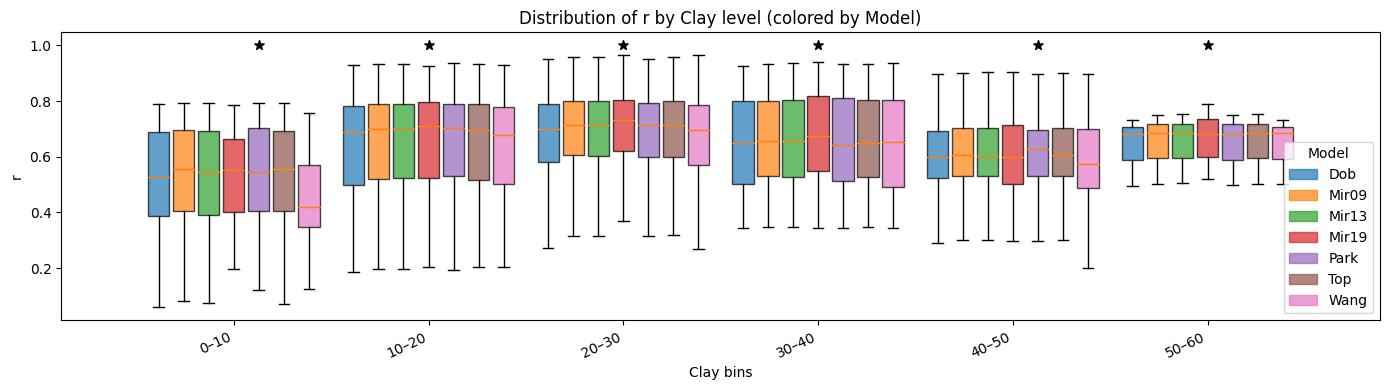

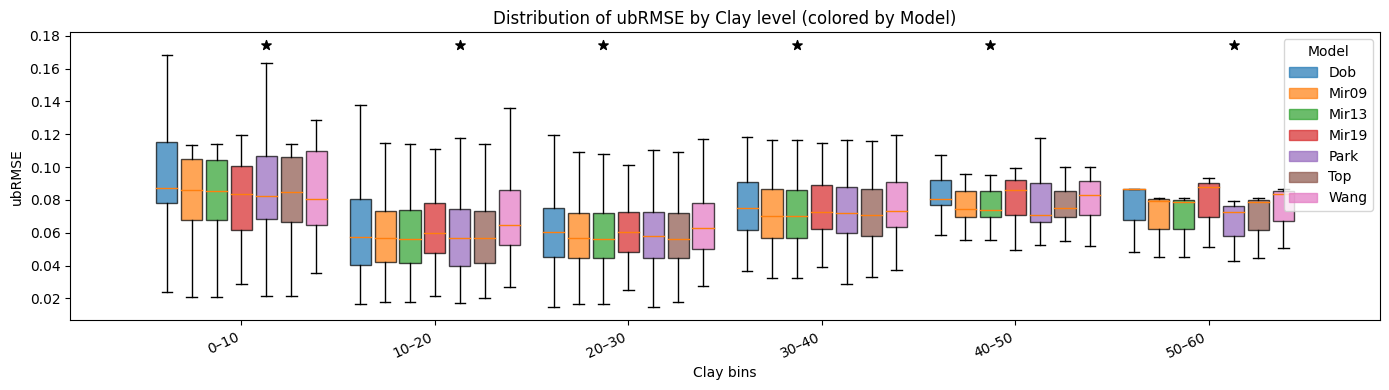

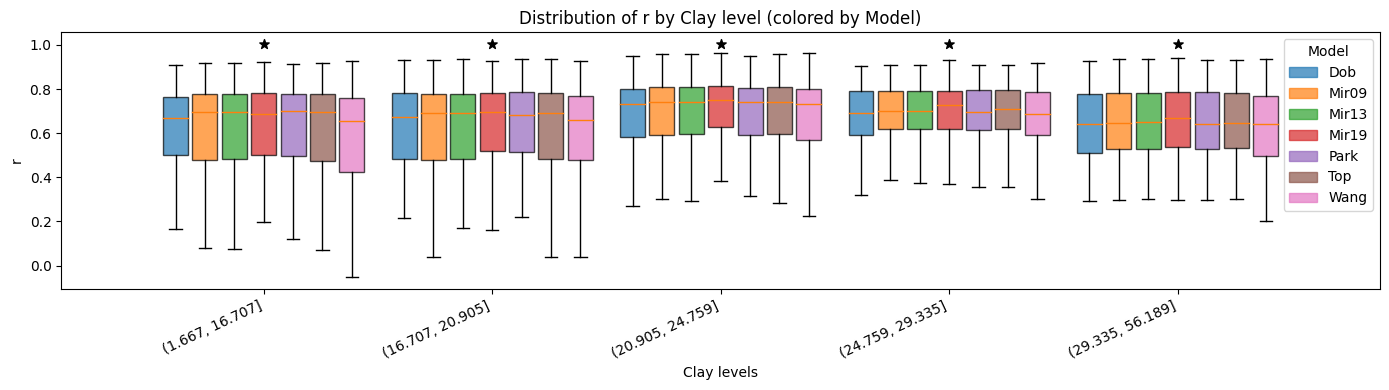

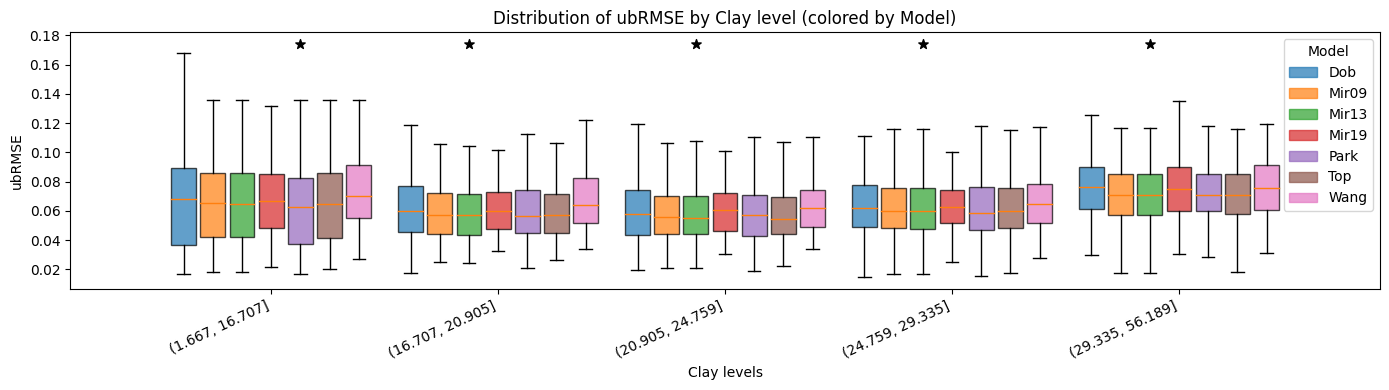

In [154]:
clay_bins = np.arange(0, 60+10, 10)
stats_clay = boxplot_eta_by_level_with_stats(df, xcol="Clay", ycol="r", bins=clay_bins)
stats_clay = boxplot_eta_by_level_with_stats(df, xcol="Clay", ycol="ubRMSE", bins=clay_bins)
stats_clay = boxplot_eta_by_level_with_stats(df, xcol="Clay", ycol="r", n_bins=5, binning="quantile")
stats_clay = boxplot_eta_by_level_with_stats(df, xcol="Clay", ycol="ubRMSE", n_bins=5, binning="quantile")

##### 有机质

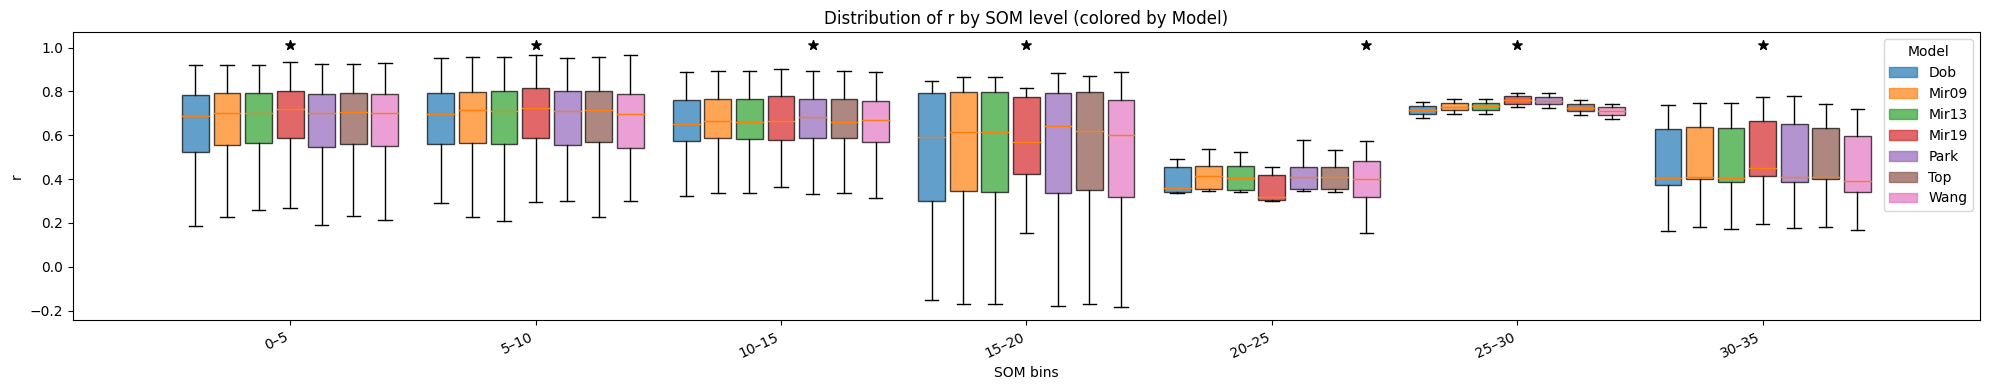

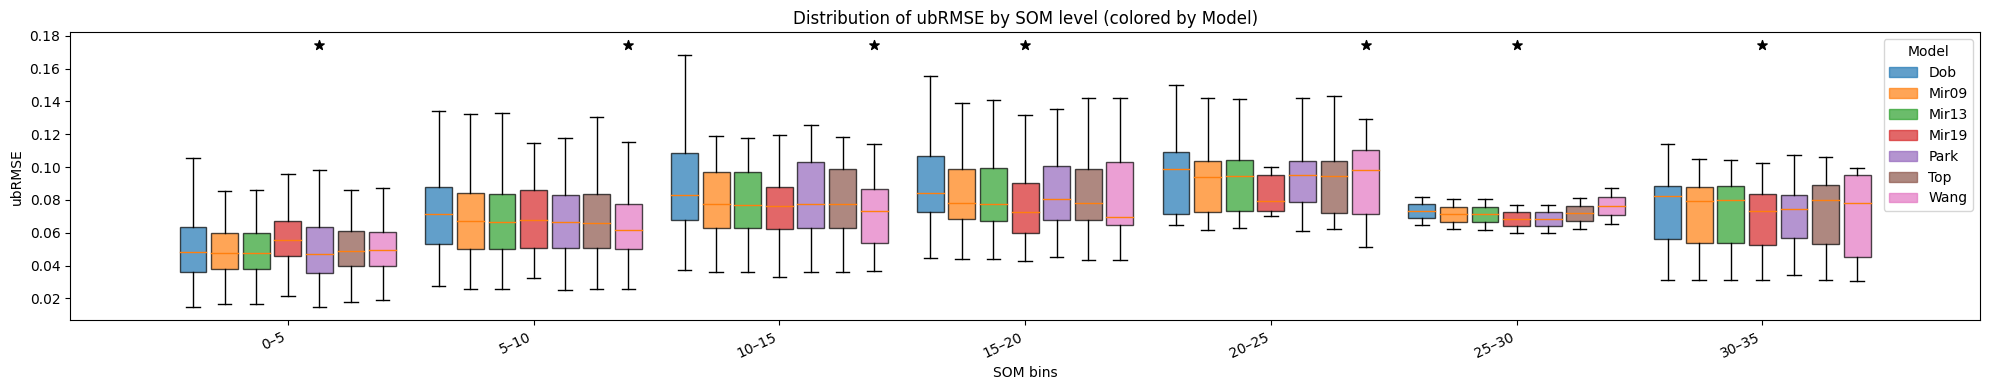

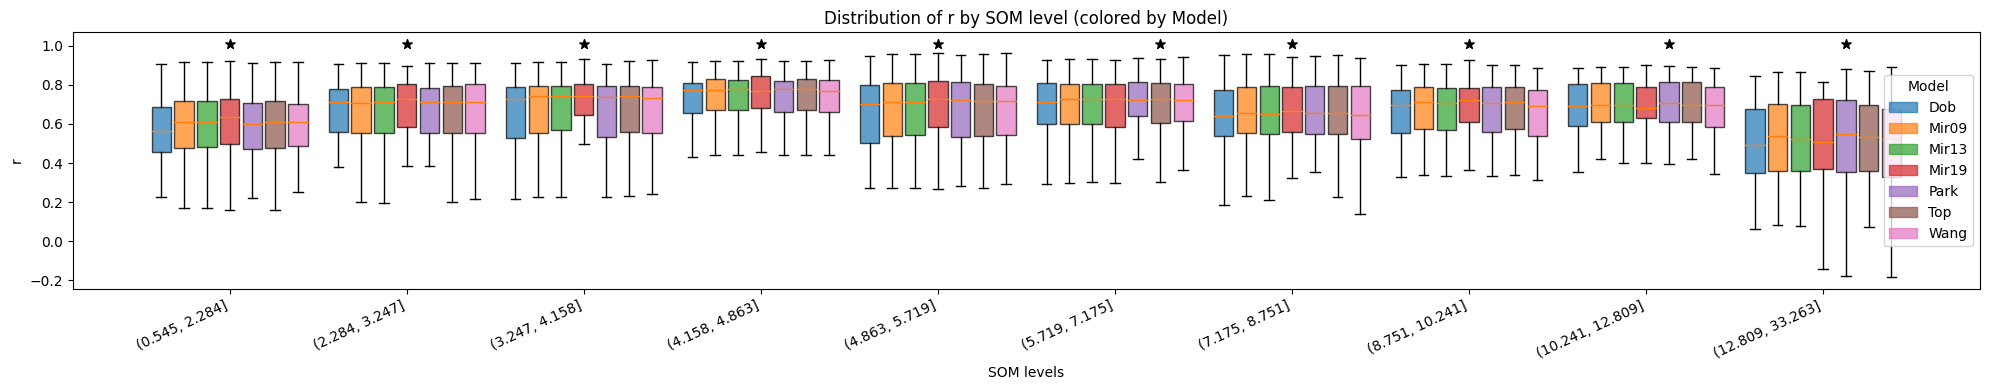

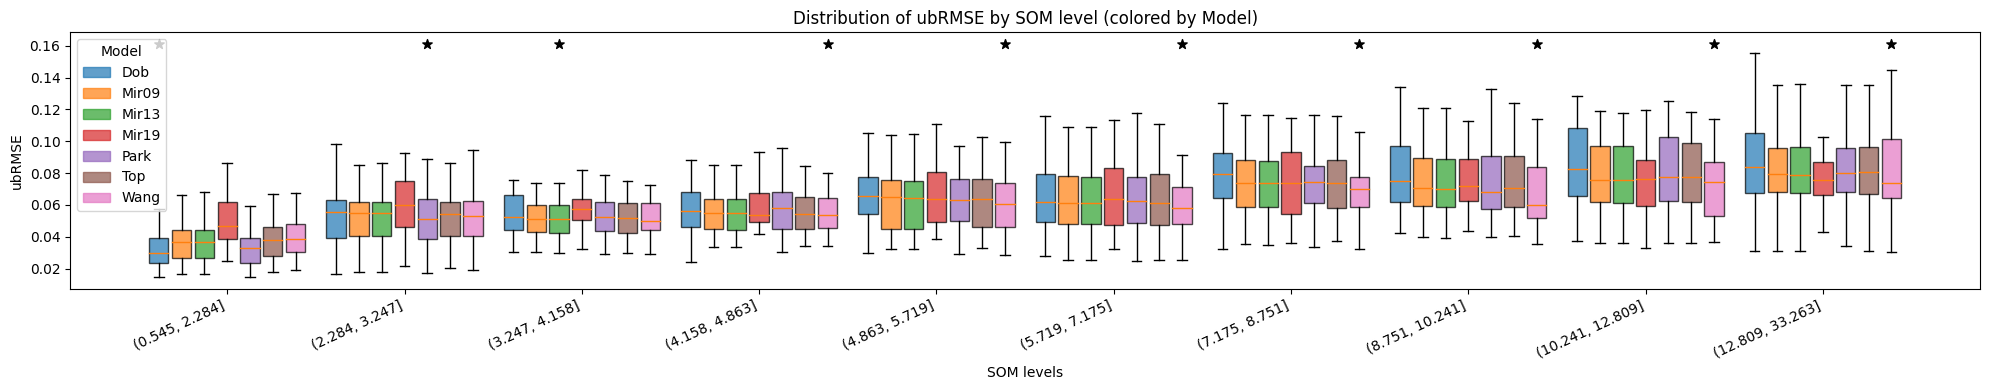

In [8]:
max_som = df["SOM"].max()
som_bins = np.arange(0, np.ceil(max_som/5)*5 + 5, 5)  # 0,10,20,...覆盖最大值
stats_som = boxplot_eta_by_level_with_stats(df, xcol="SOM", ycol="r", bins=som_bins)
stats_som = boxplot_eta_by_level_with_stats(df, xcol="SOM", ycol="ubRMSE", bins=som_bins)
stats_som = boxplot_eta_by_level_with_stats(df, xcol="SOM", ycol="r", n_bins=10, binning="quantile")
stats_som = boxplot_eta_by_level_with_stats(df, xcol="SOM", ycol="ubRMSE", n_bins=10, binning="quantile")


##### 植被

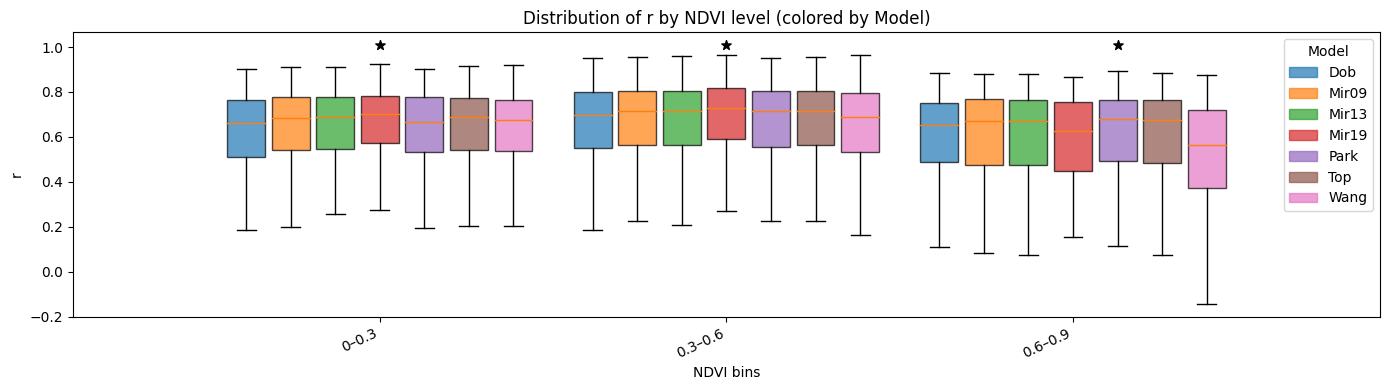

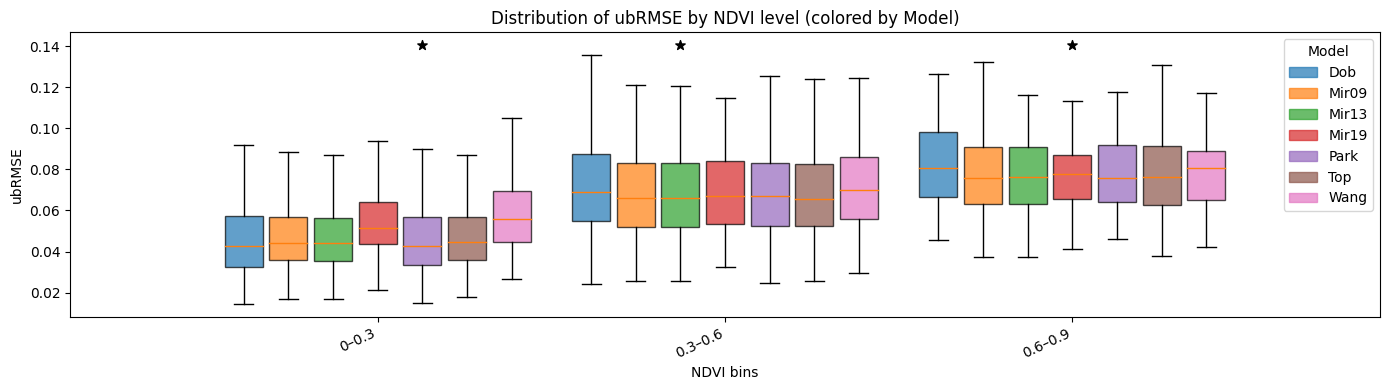

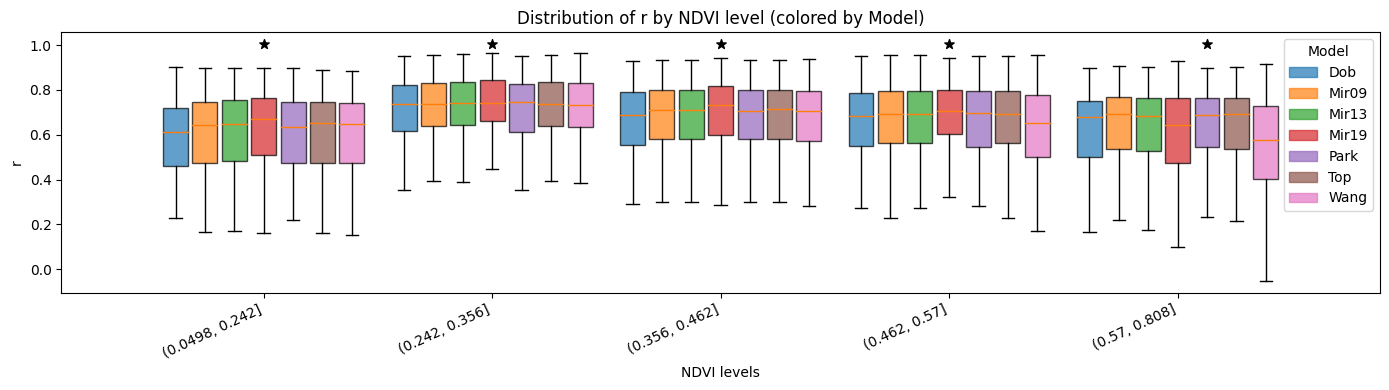

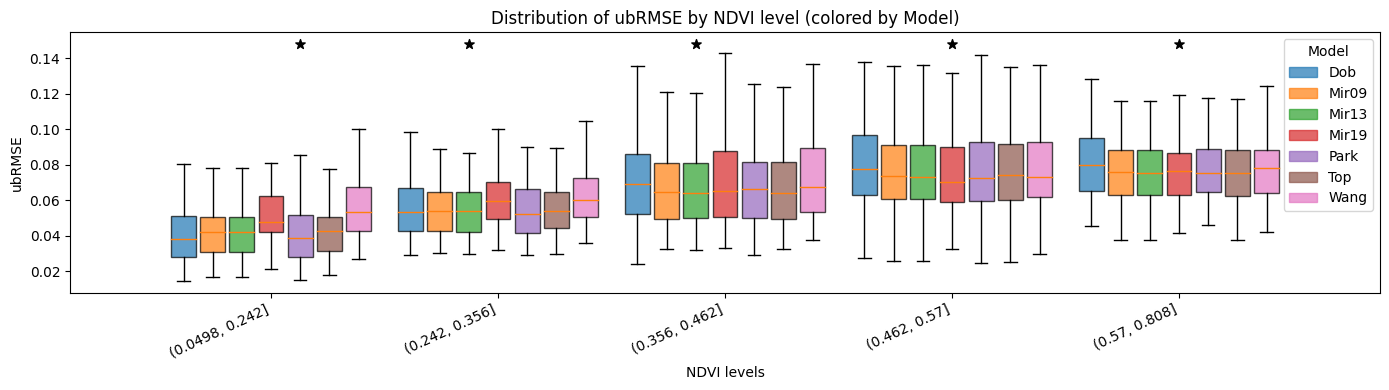

In [159]:
max_ndvi = df["NDVI"].max()
ndvi_bins = np.arange(0, np.ceil(max_ndvi/0.3)*0.3 + 0.3, 0.3) 
stats_ndvi = boxplot_eta_by_level_with_stats(df, xcol="NDVI", ycol="r", bins=ndvi_bins)
stats_ndvi = boxplot_eta_by_level_with_stats(df, xcol="NDVI", ycol="ubRMSE", bins=ndvi_bins)
stats_ndvi = boxplot_eta_by_level_with_stats(df, xcol="NDVI", ycol="r", n_bins=5, binning="quantile")
stats_ndvi = boxplot_eta_by_level_with_stats(df, xcol="NDVI", ycol="ubRMSE", n_bins=5, binning="quantile")

##### 温度

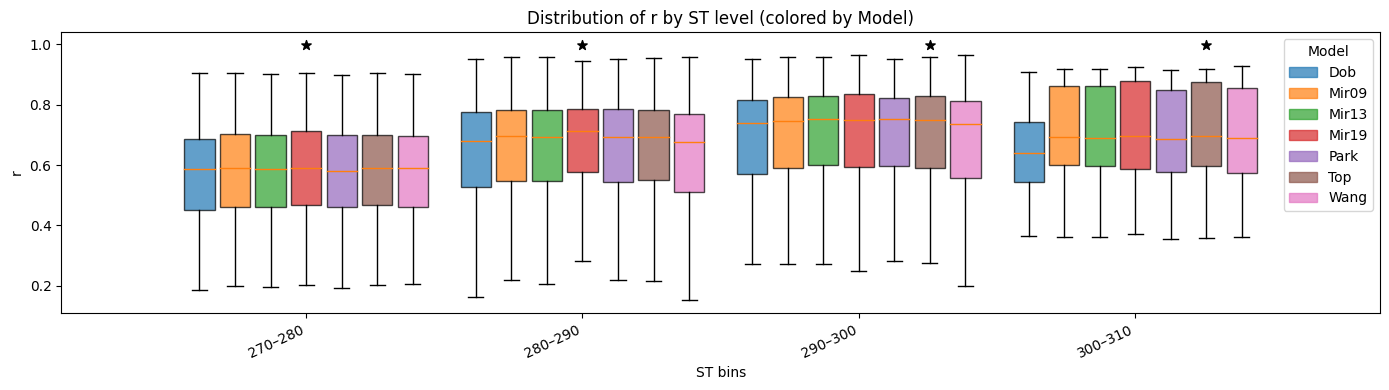

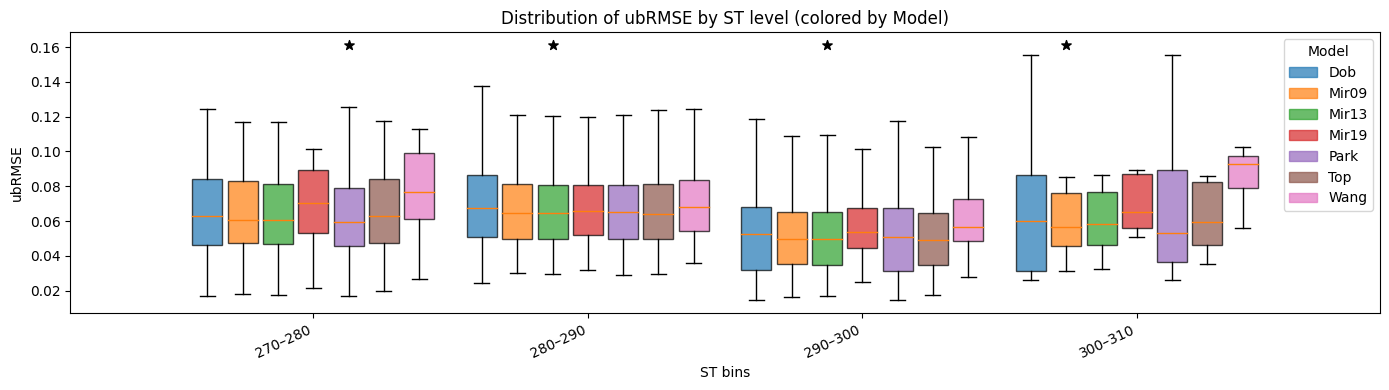

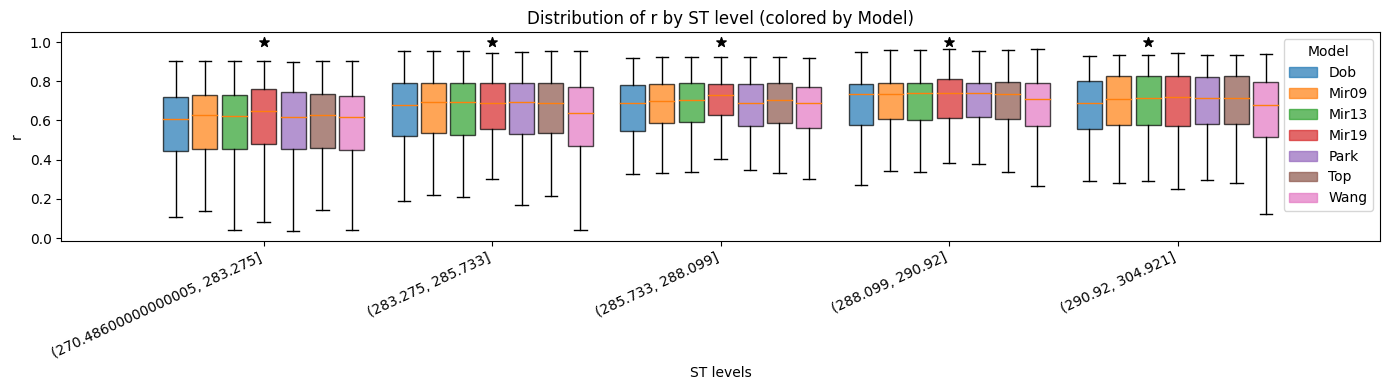

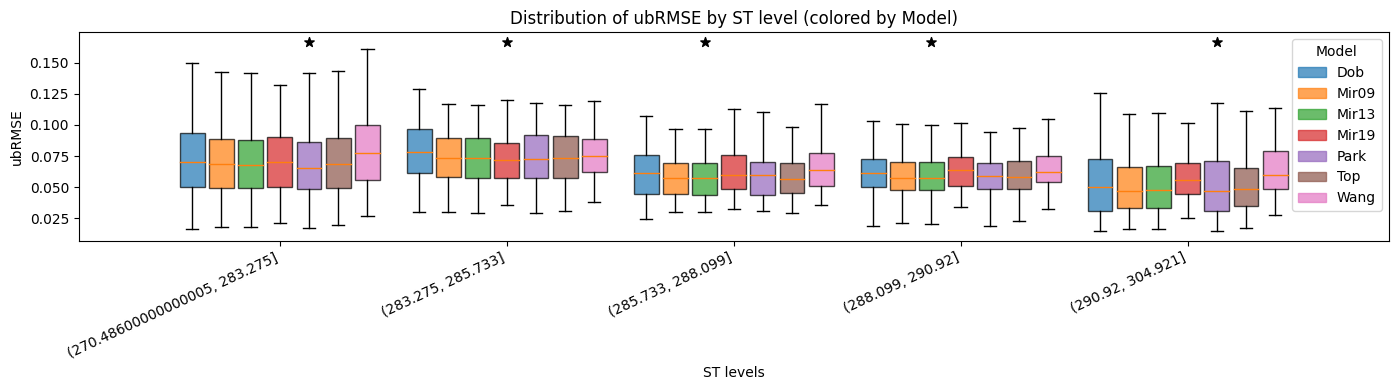

In [161]:
max_st = df["ST"].max()
st_bins = np.arange(270, np.ceil(max_st/10)*10 + 10, 10) 
stats_st = boxplot_eta_by_level_with_stats(df, xcol="ST", ycol="r", bins=st_bins)
stats_st = boxplot_eta_by_level_with_stats(df, xcol="ST", ycol="ubRMSE", bins=st_bins)
stats_st = boxplot_eta_by_level_with_stats(df, xcol="ST", ycol="r", n_bins=5, binning="quantile")
stats_st = boxplot_eta_by_level_with_stats(df, xcol="ST", ycol="ubRMSE", n_bins=5, binning="quantile")